In [71]:
import numpy as np
import matplotlib.pyplot as plt
import rasterio
import datetime
from pathlib import Path
from os import path

from rasterio.plot import plotting_extent
from matplotlib.colors import ListedColormap

import xarray as xr
import cartopy.crs as ccrs
import cartopy.feature as cfeature

from netCDF4 import Dataset
from wrf import getvar, get_cartopy, latlon_coords

## Formula

### Plot

In [72]:
def plot(lats, lons, data, title, cmap='RdYlBu_r', units='', vmin=None, vmax=None):
    fig, ax = plt.subplots(figsize=(10, 8), 
                           subplot_kw={'projection': ccrs.PlateCarree()})
    sc = ax.scatter(lons, lats, 
                    c=data, s=0.5, 
                    transform=ccrs.PlateCarree(), 
                    cmap=cmap, vmin=vmin, vmax=vmax)
    
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
    ax.add_feature(cfeature.BORDERS, linewidth=0.3)
    ax.add_feature(cfeature.STATES, linewidth=0.3)
    ax.gridlines(draw_labels=True, linewidth=0.3, alpha=0.5)

    # marker at 57.6498, -122.1530 (Donnie Creek, BC)
    ax.scatter(-122.1530, 57.6498, s=20, color='red', marker='*',
               transform=ccrs.PlateCarree(), zorder=5)

    plt.colorbar(sc, label=units, shrink=0.6)
    ax.set_title(title)
    plt.tight_layout()
    plt.show()

def plot_zoom(lats, lons, data, title, cmap='RdYlBu_r', units='', vmin=None, vmax=None):
    fig, ax = plt.subplots(figsize=(10, 8), 
                           subplot_kw={'projection': ccrs.PlateCarree()})
    sc = ax.scatter(lons, lats, 
                    c=data, s=0.5, 
                    transform=ccrs.PlateCarree(), 
                    cmap=cmap, vmin=vmin, vmax=vmax)
    
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
    ax.add_feature(cfeature.BORDERS, linewidth=0.3)
    ax.add_feature(cfeature.STATES, linewidth=0.3)
    ax.gridlines(draw_labels=True, linewidth=0.3, alpha=0.5)

    # zoom in to the region of interest
    ax.set_extent([-112.5, -130, 52, 62.5], crs=ccrs.PlateCarree()) 
    # marker at 57.6498, -122.1530 (Donnie Creek, BC)
    ax.scatter(-122.1530, 57.6498, s=20, color='red', marker='*',
               transform=ccrs.PlateCarree(), zorder=5)

    plt.colorbar(sc, label=units, shrink=0.6)
    ax.set_title(title)
    plt.tight_layout()
    plt.show()

### Calculations

In [ ]:
# Relative Humidity Calculation Function
def calc_rh_from_t_td(t_kelvin, td_kelvin):
    """
    Calculate relative humidity (%) from 2-m temperature and 2-m dewpoint temperature (both in Kelvin), 
    using the Bolton (1980) saturation vapor pressure approximation:

        e_s(T) = 6.112 * exp( 17.67 * T_C / (T_C + 243.5) )   [hPa]
        RH     = 100 * e_s(Td) / e_s(T)
        
    where T_C is temperature in Celsius.
    """
    t_c = t_kelvin - 273.15
    td_c = td_kelvin - 273.15
    e_s_t = 6.112 * np.exp((17.67 * t_c) / (t_c + 243.5))
    e_s_td = 6.112 * np.exp((17.67 * td_c) / (td_c + 243.5))
    return 100 * (e_s_td / e_s_t)

# Files

In [6]:
# File paths
wrf_dir = "/Volumes/jchen/Share_Forecasts/WAC00WG-01/23050800/wrfout_d02_2023-05-08_03:00:00"
ai_bc_dir = "/Users/jchen/Anemoi/ignition/bc/08-10/20230508T00.nc"
ai_norway_dir = "/Users/jchen/Anemoi/ignition/norway/08-10/20230508T00.nc"

# Files
wrf = Dataset(wrf_dir)
ai_bc = Dataset(ai_bc_dir)
ai_norway = Dataset(ai_norway_dir)

wrf_xr = xr.open_dataset(wrf_dir)
ai_bc_xr = xr.open_dataset(ai_bc_dir)
ai_norway_xr = xr.open_dataset(ai_norway_dir)

### Pressure

In [ ]:
ai_dir = "~/Anemoi/ignition/bc/08-10/20230508T00.nc"
ai = xr.open_dataset(ai_dir, engine='netcdf4')

ai_tds = ai.sel(lead_time=ai.lead_time[0])
ai_var1 = 'sp'
# ai_var2 = ''
ai_data = ai_tds[ai_var1].values / 1000  # Convert to kPa

ai_lat  = ai_tds['latitude'].values
ai_lon  = ai_tds['longitude'].values

plot(ai_lat, ai_lon, ai_data,
         title='Anemoi Ignition Surface Pressure (kPa) - Leadtime 0h',
         cmap='RdYlBu_r', units='kPa', vmin=80, vmax=100)

plot_zoom(ai_lat, ai_lon, ai_data,
         title='Anemoi Ignition Surface Pressure (kPa) - Leadtime 0h',
         cmap='RdYlBu_r', units='kPa', vmin=80, vmax=100)

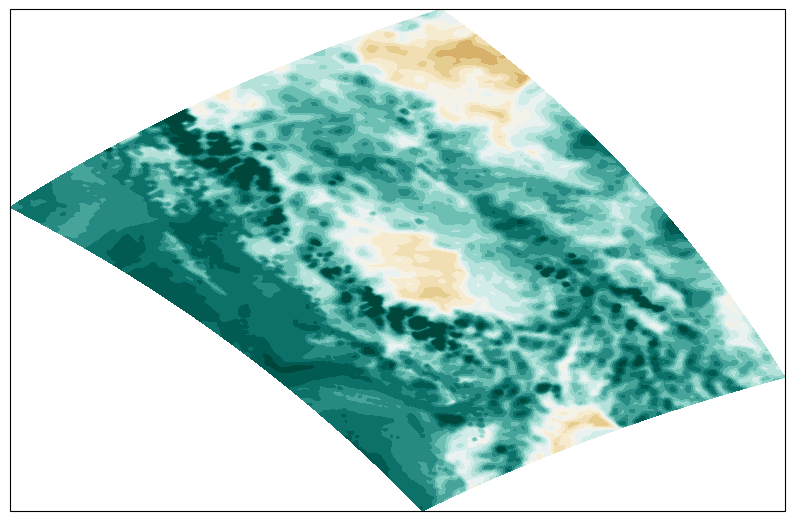

In [8]:
# WRF
wrf_rh2 = getvar(wrf, "rh2", timeidx=0)
wrf_rh2_proj = get_cartopy(wrf_rh2)
wrf_rh2_fig = plt.figure(figsize=(10, 8))
wrf_rh2_ax = plt.axes(projection=wrf_rh2_proj)
wrf_rh2_lats, wrf_rh2_lons = latlon_coords(wrf_rh2)
wrf_rh2_contours = wrf_rh2_ax.contourf(wrf_rh2_lons, wrf_rh2_lats, wrf_rh2, 
                                       cmap="BrBG",
                                       levels = range(0, 105, 5))
# wrf_rh2_ax.coastlines(linewidth=1.5)
# wrf_rh2_ax.gridlines(linestyle="--")
# plt.colorbar(wrf_rh2_contours, ax=wrf_rh2_ax, label="Relative Humidity (%)")
# plt.title("WRF 2-Meter Relative Humidity")
# plt.show()

# # AI BC
# ai_bc_rh2 = ai_bc_xr["rh2"].isel(time=0)
# ai_bc_rh2_proj = get_cartopy(ai_bc_rh2)
# ai_bc_rh2_fig = plt.figure(figsize=(10, 8))
# ai_bc_rh2_ax = plt.axes(projection=ai_bc_rh2_proj)
# ai_bc_rh2_lats, ai_bc_rh2_lons = latlon_coords(ai_bc_rh2)
# ai_bc_rh2_contours = ai_bc_rh2_ax.contourf(ai_bc_rh2_lons, ai_bc_rh2_lats, ai_bc_rh2, 
#                                           cmap="BrBG",
#                                           levels = range(0, 105, 5))
# ai_bc_rh2_ax.coastlines(linewidth=1.5)
# ai_bc_rh2_ax.gridlines(linestyle="--")
# plt.colorbar(ai_bc_rh2_contours, ax=ai_bc_rh2_ax, label="Relative Humidity (%)")
# plt.title("AI BC 2-Meter Relative Humidity")
# plt.show()

# # AI Norway
# ai_norway_rh2 = ai_norway_xr["rh2"].isel(time=0)
# ai_norway_rh2_proj = get_cartopy(ai_norway_rh2)
# ai_norway_rh2_fig = plt.figure(figsize=(10, 8))
# ai_norway_rh2_ax = plt.axes(projection=ai_norway_rh2_proj)
# ai_norway_rh2_lats, ai_norway_rh2_lons = latlon_coords(ai_norway_rh2)
# ai_norway_rh2_contours = ai_norway_rh2_ax.contourf(ai_norway_rh2_lons, ai_norway_rh2_lats, ai_norway_rh2, 
#                                                 cmap="BrBG",
#                                                 levels = range(0, 105, 5))
# ai_norway_rh2_ax.coastlines(linewidth=1.5)
# ai_norway_rh2_ax.gridlines(linestyle="--")
# plt.colorbar(ai_norway_rh2_contours, ax=ai_norway_rh2_ax, label="Relative Humidity (%)")
# plt.title("AI Norway 2-Meter Relative Humidity")
# plt.show()

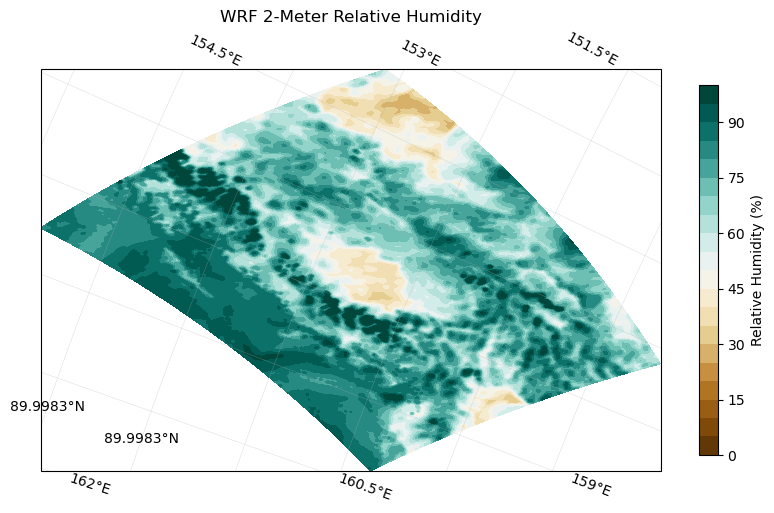

(<Figure size 1000x800 with 2 Axes>,
 <GeoAxes: title={'center': 'WRF 2-Meter Relative Humidity'}>)

In [9]:
plot_var(wrf_rh2, wrf_rh2_lats, wrf_rh2_lons, wrf_rh2_proj,
          "WRF 2-Meter Relative Humidity",
          cmap="BrBG", levels=range(0, 105, 5), cbar_label="Relative Humidity (%)")